In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [5]:
df.head()
# in this the column fireplace is a categorical data and garage qual is also a categorical data and slaes price is numerical data 

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().mean()*100 # this tells about missing values 

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

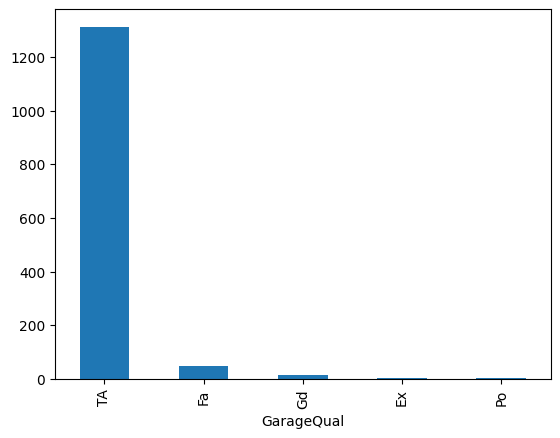

In [11]:
df['GarageQual'].value_counts().plot(kind='bar')

In [12]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQal')

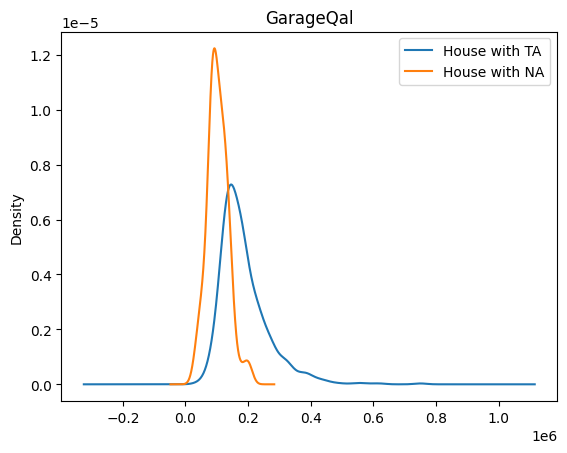

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax)

lines , labels = ax.get_legend_handles_labels()
labels = ['House with TA','House with NA']
ax.legend(lines,labels,loc='best')

plt.title("GarageQal")

In [22]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [23]:
df['GarageQual'].fillna('TA',inplace=True)

<Axes: xlabel='GarageQual'>

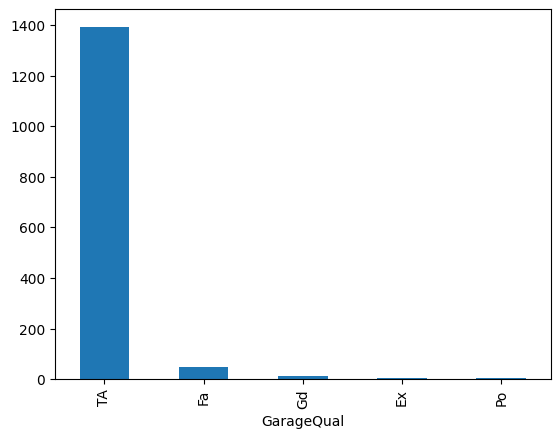

In [24]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

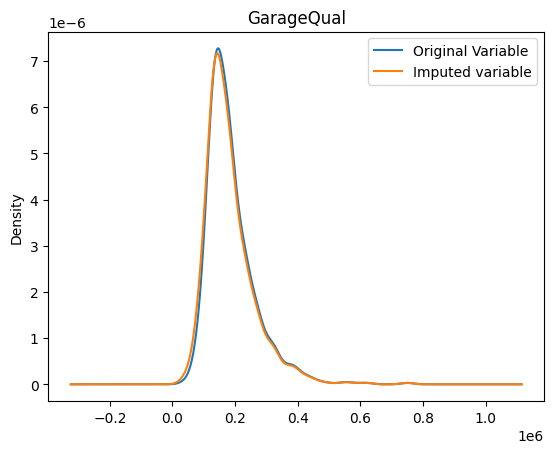

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax)

lines , labels = ax.get_legend_handles_labels()
labels = ['Original Variable','Imputed variable']
ax.legend(lines,labels,loc='best')

plt.title("GarageQual") # there is no difference or very little difference between the original data and imputed data so we can say that the distribution does not change too much so we can apply this mode method to fill this particular column.

<Axes: xlabel='FireplaceQu'>

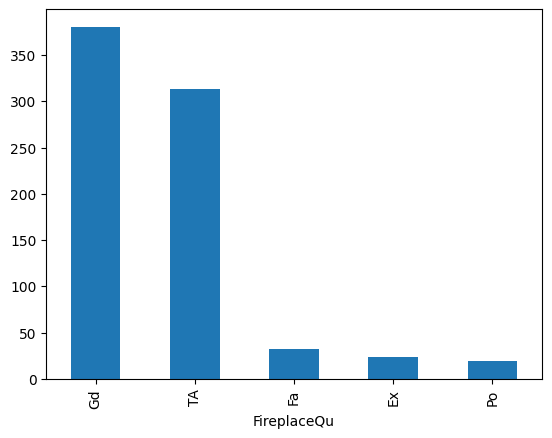

In [ ]:
df['FireplaceQu'].value_counts().plot(kind='bar') # we can see the that the mode 'GD' and the column TA do not have too much difference so while using mode method it might be possible that we can't able to see correct or appropriate resilt.

In [28]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

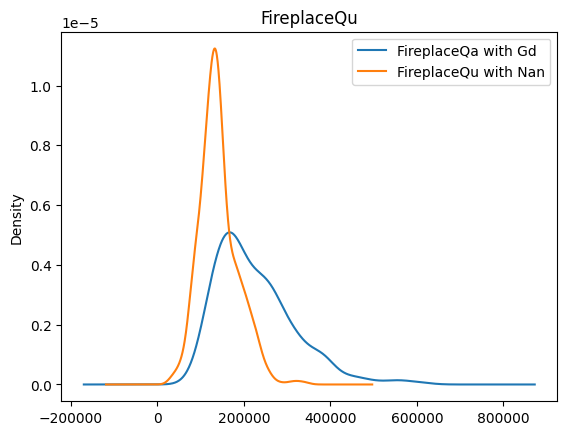

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax)

lines,labels = ax.get_legend_handles_labels()
labels = ['FireplaceQa with Gd','FireplaceQu with Nan']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')

In [32]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [33]:
df['FireplaceQu'].fillna('Gd',inplace=True)

<Axes: xlabel='FireplaceQu'>

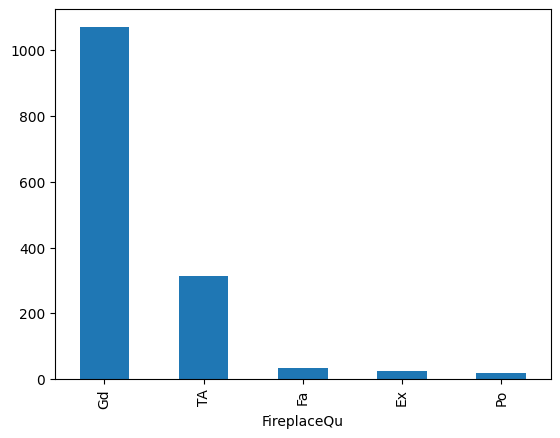

In [34]:
df['FireplaceQu'].value_counts().plot(kind='bar')

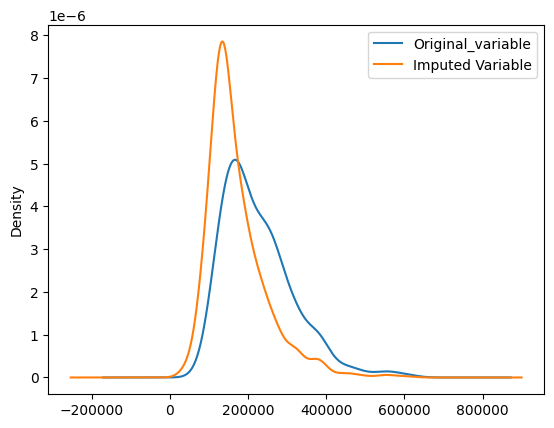

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)

lines,labels = ax.get_legend_handles_labels()
labels = ['Original_variable','Imputed Variable']
ax.legend(lines,labels,loc='best')

# after imputation there is too much difference in the distribution so it is not good or give better result if we use this mode technique to this FireplaceQu column 

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=42)

In [38]:
from sklearn.impute import SimpleImputer

In [39]:
imputer = SimpleImputer(strategy='most_frequent')

In [40]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)


In [41]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)